# Análisis Exploratorio de Datos (EDA) - Dry Beans Dataset

Este notebook presenta el análisis exploratorio de datos del conjunto de datos de granos de frijol secos. El objetivo es comprender la estructura de los datos, evaluar la calidad de la información y analizar el poder discriminativo de las variables morfológicas para la clasificación de las variedades.

## 1. Adquisición y Carga de Datos

In [1]:
!wget https://raw.githubusercontent.com/soydz/dry-bean-ai-analysis/main/data/Dry_Beans_Dataset.csv

--2026-05-19 23:28:19--  https://raw.githubusercontent.com/soydz/dry-bean-ai-analysis/main/data/Dry_Beans_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2663219 (2.5M) [text/plain]
Saving to: ‘Dry_Beans_Dataset.csv’

Dry_Beans_Dataset.c 100%[===================>]   2.54M  --.-KB/s    in 0.01s   

2026-05-19 23:28:20 (263 MB/s) - ‘Dry_Beans_Dataset.csv’ saved [2663219/2663219]



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Dry_Beans_Dataset.csv')

## 2. Inspección Inicial

In [4]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [6]:
df.shape

(13611, 17)

## 3. Análisis Descriptivo

In [7]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

## 4. Auditoría de Calidad de Datos

In [9]:
df[df.duplicated()]

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7263,63408,1005.966,412.551649,196.337705,2.101235,0.879494,64200,284.136540,0.798791,0.987664,0.787385,0.688730,0.006506,0.000903,0.474348,0.996718,HOROZ
7278,63882,1004.206,411.263403,198.765453,2.069089,0.875452,64663,285.196579,0.754705,0.987922,0.796054,0.693465,0.006438,0.000918,0.480893,0.995010,HOROZ
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ


In [10]:
# Verificación de integridad
if (df.duplicated().sum() != 0):
  print("⚠️ Hay filas duplicadas exactas")

if (df.isnull().sum().sum() != 0):
  print("⚠️ Hay valores NaN")

features = df.drop(columns=['Class'])
if not (features.select_dtypes(exclude="number").empty):
  print("⚠️ Hay features no numéricas")

expected_classes = {'DERMASON', 'SIRA', 'SEKER', 'HOROZ', 'CALI', 'BARBUNYA', 'BOMBAY'}
if(set(df['Class'].unique()) != expected_classes):
  print("⚠️ Clases inesperadas")

⚠️ Hay filas duplicadas exactas


In [11]:
duplicados = df.duplicated()
print("Duplicados:", duplicados.sum(), "registros")

Duplicados: 68 registros


In [12]:
df[duplicados].head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5548,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
5554,38891,791.343,319.499996,156.869619,2.036723,0.871168,39651,222.525412,0.650025,0.980833,0.780422,0.696480,0.008215,0.001192,0.485085,0.987983,HOROZ
5599,40804,790.802,323.475648,163.287717,1.981016,0.863241,41636,227.932592,0.787570,0.980017,0.819931,0.704636,0.007928,0.001206,0.496512,0.983598,HOROZ
5623,41978,821.864,337.171464,160.036067,2.106847,0.880178,42593,231.188342,0.684885,0.985561,0.780965,0.685670,0.008032,0.001095,0.470143,0.990520,HOROZ
5631,42156,815.245,335.198243,160.936938,2.082792,0.877200,42586,231.677980,0.834046,0.989903,0.797064,0.691167,0.007951,0.001119,0.477712,0.994975,HOROZ
5639,42450,828.116,347.951525,156.469366,2.223768,0.893186,42820,232.484448,0.609388,0.991359,0.777867,0.668152,0.008197,0.001008,0.446427,0.992750,HOROZ
5659,43099,815.390,328.234078,168.610116,1.946705,0.857977,43710,234.254885,0.697666,0.986022,0.814604,0.713682,0.007616,0.001219,0.509343,0.991539,HOROZ
5679,43746,836.693,339.352567,165.411442,2.051566,0.873161,44442,236.006646,0.713778,0.984339,0.785264,0.695462,0.007757,0.001119,0.483667,0.992274,HOROZ


## 5. Análisis de la Variable Objetivo

In [13]:
df.Class.value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


[Text(0, 0, '3546'),
 Text(0, 0, '2636'),
 Text(0, 0, '2027'),
 Text(0, 0, '1928'),
 Text(0, 0, '1630'),
 Text(0, 0, '1322'),
 Text(0, 0, '522')]

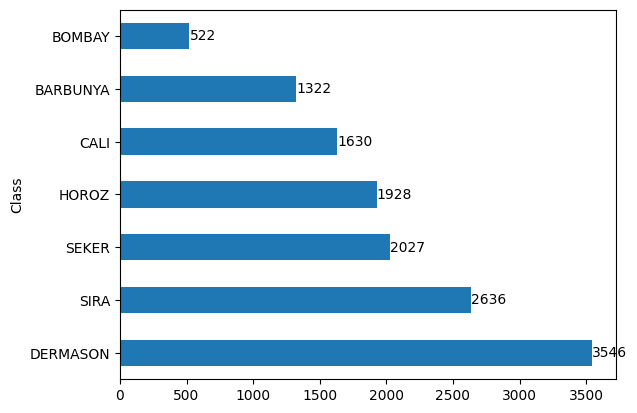

In [14]:
barh = df.Class.value_counts().plot(kind="barh")
barh.bar_label(barh.containers[0])

<Axes: ylabel='count'>

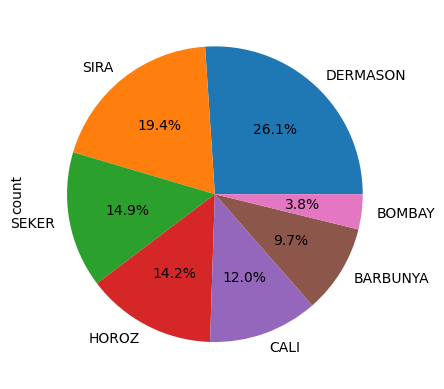

In [15]:
df.Class.value_counts().plot(kind="pie", autopct="%1.1f%%")

## 6. Descripción de Variables

El dataset contiene **16 variables predictoras** extraídas de imágenes de granos
de frijol mediante un sistema de visión por computador:

| # | Variable | Tipo | Descripción |
|---|----------|------|-------------|
| 1 | Area | Entero | Número de píxeles dentro del contorno del grano |
| 2 | Perimeter | Real | Longitud del borde del grano |
| 3 | MajorAxisLength | Real | Distancia entre extremos de la línea más larga |
| 4 | MinorAxisLength | Real | Línea más larga perpendicular al eje mayor |
| 5 | AspectRation | Real | Relación L/l (eje mayor / eje menor) |
| 6 | Eccentricity | Real | Excentricidad de la elipse equivalente |
| 7 | ConvexArea | Entero | Píxeles del polígono convexo mínimo |
| 8 | EquivDiameter | Real | Diámetro del círculo con igual área |
| 9 | Extent | Real | Razón píxeles del bounding box vs área |
| 10 | Solidity | Real | Razón píxeles del casco convexo vs grano |
| 11 | roundness | Real | (4πA) / P² |
| 12 | Compactness | Real | Ed / L |
| 13–16 | ShapeFactor1–4 | Real | Factores de forma adicionales |
| 17 | Class | Categórica | Variedad del frijol (7 clases) |

## 7. Análisis de Distribución y Poder Discriminativo

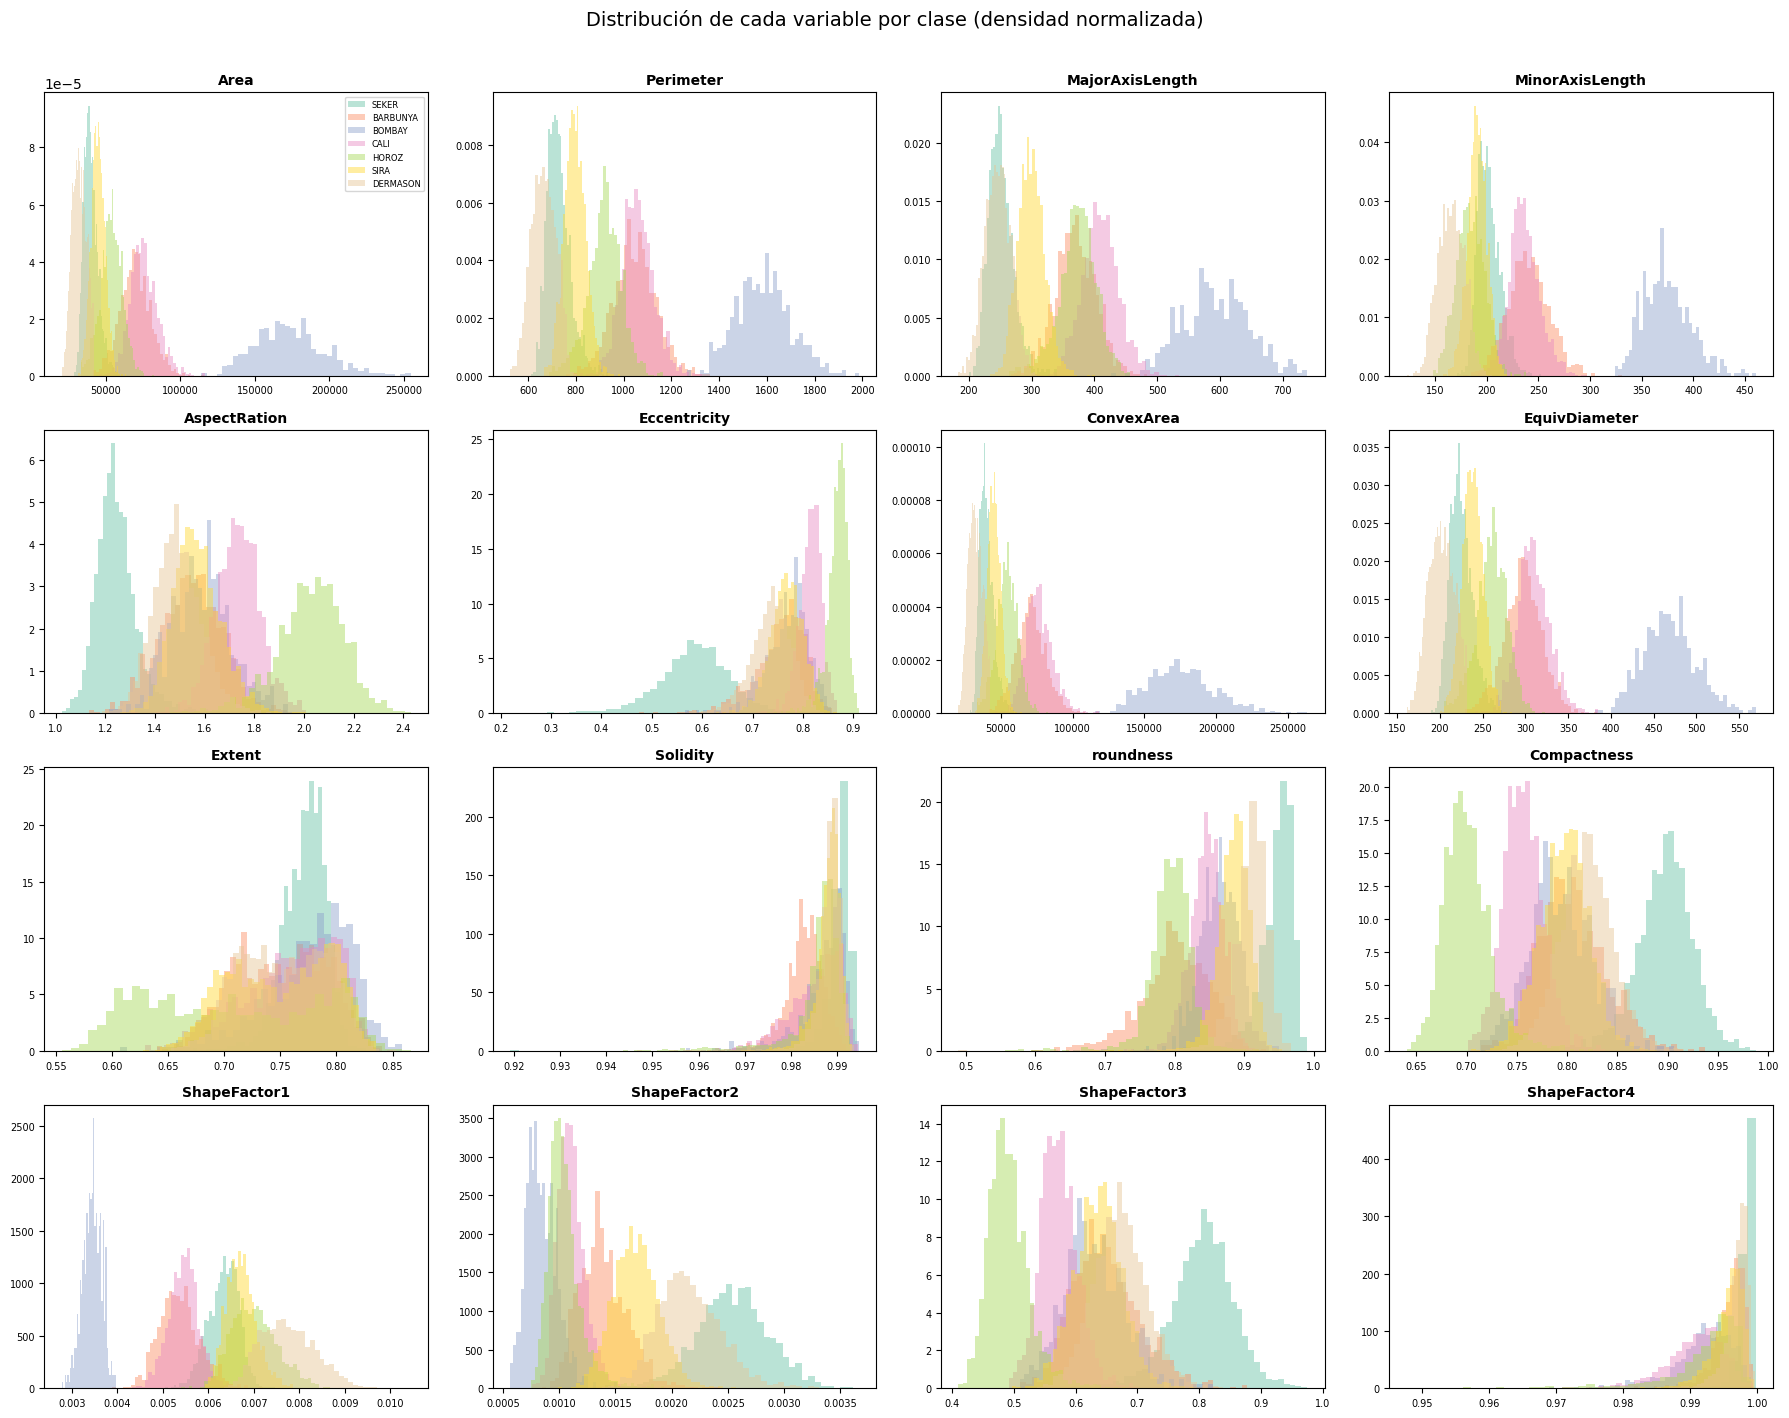

In [16]:
# Histogramas normalizados por clase
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

class_names = df['Class'].unique()
palette = sns.color_palette("Set2", len(class_names))

for i, col in enumerate(features):
    for j, cls in enumerate(class_names):
        subset = df[df['Class'] == cls][col]
        axes[i].hist(subset, bins=40, alpha=0.45, label=cls, density=True, color=palette[j])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=7)

axes[0].legend(fontsize=6, loc='upper right')
plt.suptitle("Distribución de cada variable por clase (densidad normalizada)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fig3_histograms_by_class.png", bbox_inches='tight')
plt.show()

**Observaciones:**
- Variables como `Area`, `Perimeter`, `MajorAxisLength`, `ConvexArea`, `EquivDiameter`
  presentan distribuciones claramente multimodales, lo cual sugiere buen poder discriminativo.
- La variedad BOMBAY se separa claramente en las variables de tamaño (valores mucho mayores).
- Variables de forma (`Compactness`, `Eccentricity`, `roundness`, `ShapeFactor1-4`)
  muestran solapamiento considerable entre algunas clases (especialmente SIRA vs DERMASON).

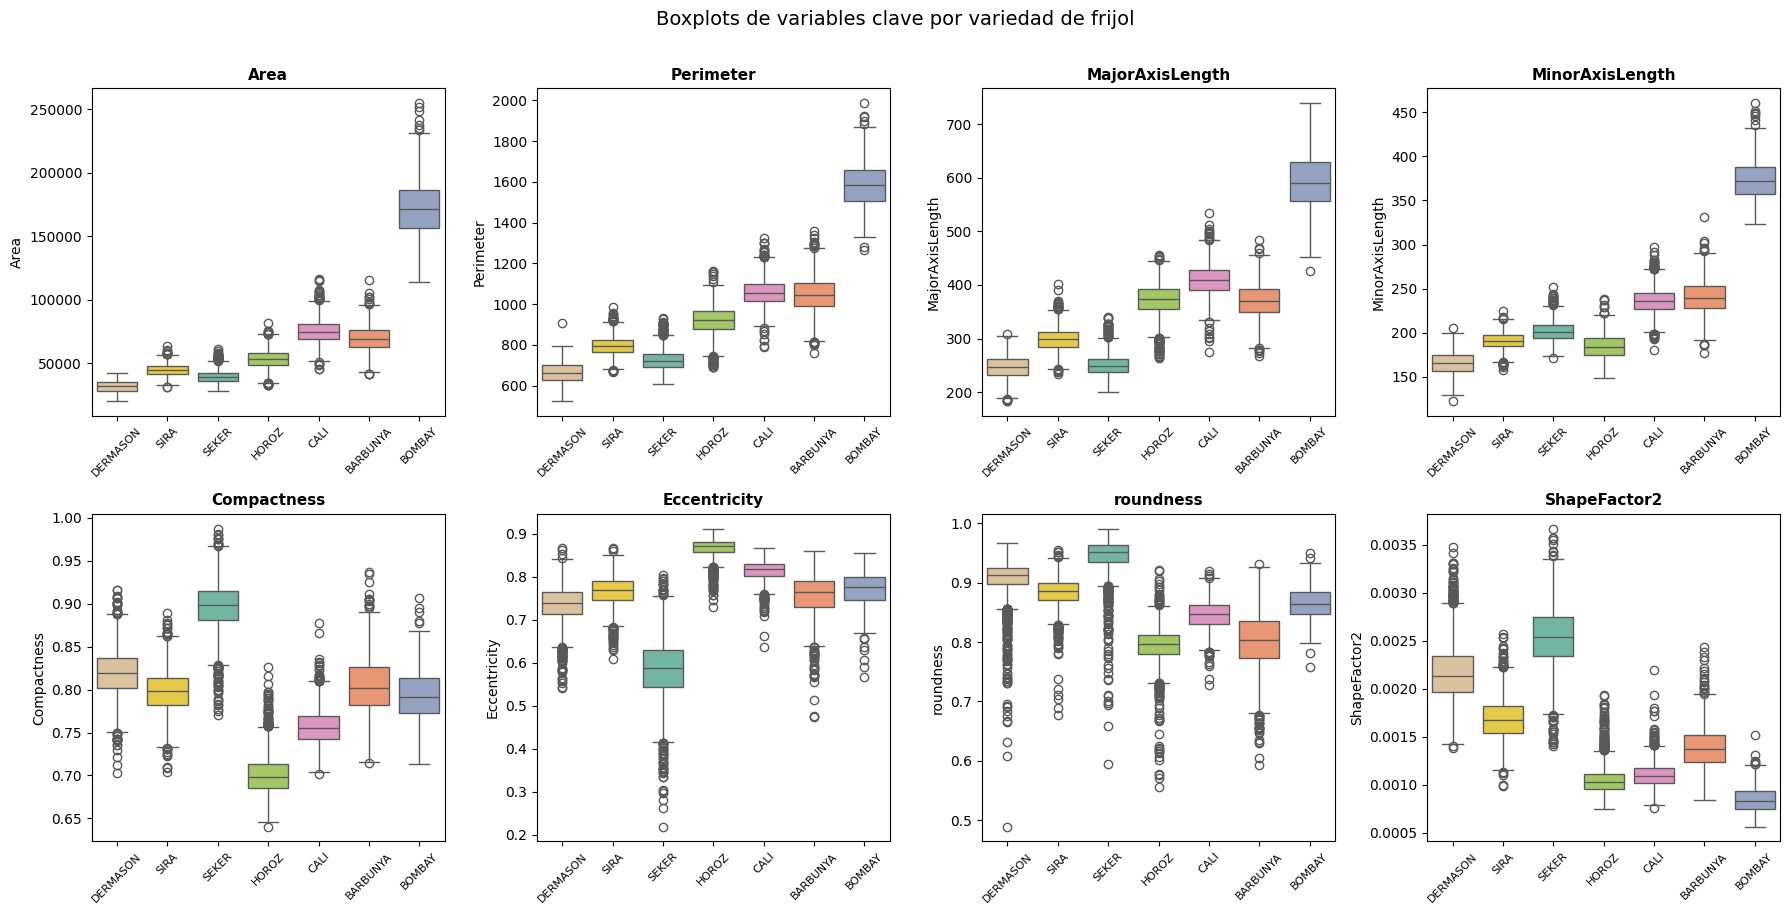

In [17]:
# Boxplots de variables clave por clase
key_features = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                'Compactness', 'Eccentricity', 'roundness', 'ShapeFactor2']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

order = df['Class'].value_counts().index  # Ordenadas por frecuencia

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='Class', y=col, ax=axes[i], palette='Set2',
                order=order, hue='Class', legend=False)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].set_xlabel("")

plt.suptitle("Boxplots de variables clave por variedad de frijol", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fig4_boxplots_key_features.png", bbox_inches='tight')
plt.show()

## 8. Análisis de Correlación

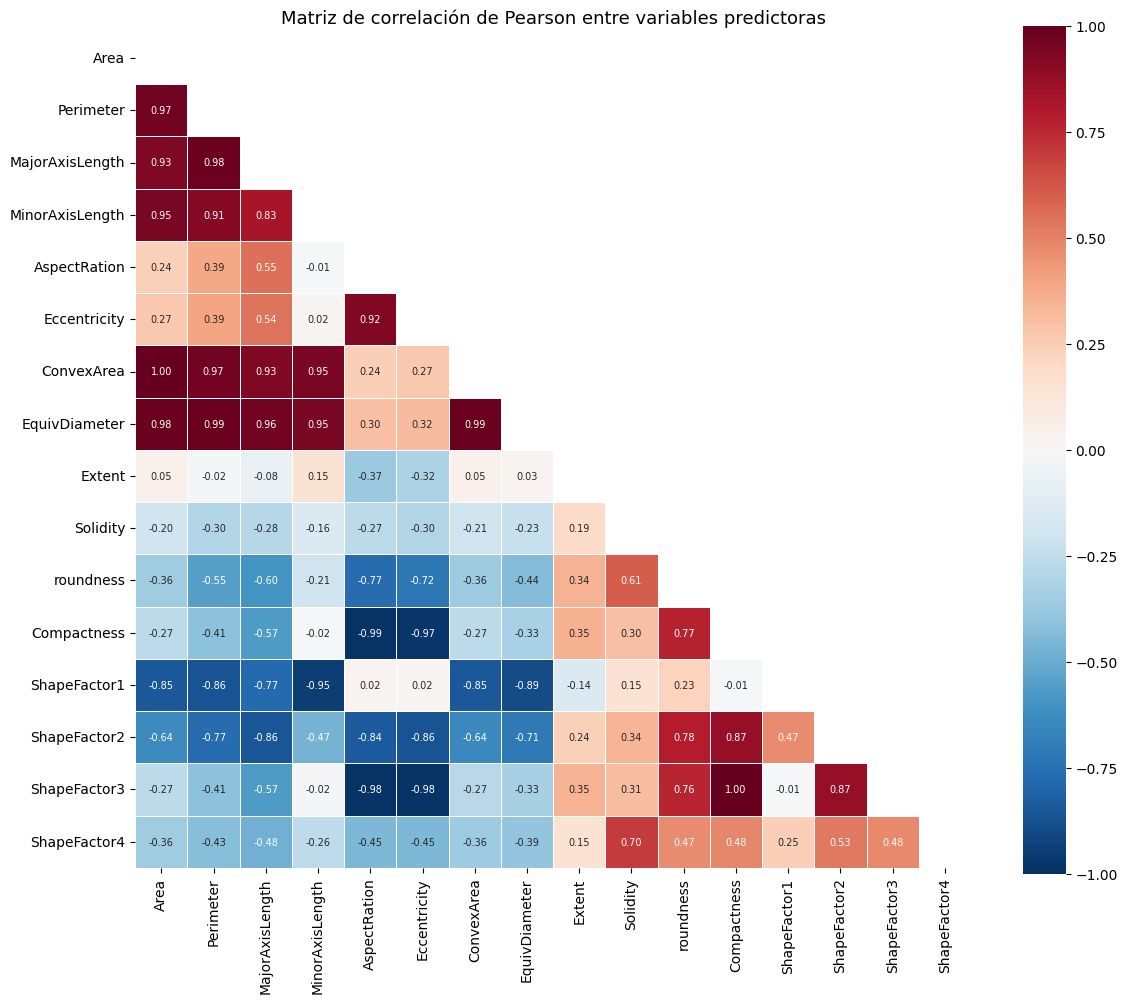

In [18]:
corr = features.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 7}, vmin=-1, vmax=1)
ax.set_title("Matriz de correlación de Pearson entre variables predictoras", fontsize=13)
plt.tight_layout()
plt.savefig("fig2_correlation_matrix.png", bbox_inches='tight')
plt.show()

## 9. Conclusiones del EDA

1. **Calidad de Datos**: Se identificaron 68 registros duplicados que deben ser tratados antes del modelado.
2. **Balance de Clases**: El dataset presenta un desbalance moderado, siendo DERMASON la clase más frecuente y BOMBAY la menos frecuente.
3. **Poder Discriminativo**: Las variables de tamaño (`Area`, `Perimeter`) son altamente efectivas para separar la variedad BOMBAY del resto. Las variables de forma muestran mayor solapamiento, lo que sugiere que el modelo requerirá de combinaciones no lineales de características para distinguir clases similares como SIRA y DERMASON.
4. **Colinealidad**: Existe una correlación muy alta entre el área, el perímetro y el diámetro equivalente, lo que indica redundancia en la información de tamaño.